1. Import Library

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

2. LOAD DATA

In [38]:
df = pd.read_csv("lda_nmf.csv")

print("Jumlah data:", len(df))
df.head()

Jumlah data: 4000


,id_berita,judul,isi_berita,kategori
0,1,Mensesneg Sebut Tokoh Oposisi yang Bertemu Pra...,Menteri Sekretaris Negara (Mensesneg) Prasetyo...,politik
1,2,Cak Imin: PKB Realistis Dukung Prabowo di Pemi...,KETUA Umum Partai Kebangkitan Bangsa Abdul Muh...,politik
2,3,DPRD Surabaya minta lokasi parkir ditutup jika...,Surabaya (ANTARA) - Wakil Ketua Dewan Perwakil...,politik
3,4,Presiden: Dana penertiban Satgas PKH untuk per...,Jakarta (ANTARA) - Presiden Prabowo Subianto m...,politik
4,5,Cucun minta kader PKB hadir setiap saat di ten...,Jakarta (ANTARA) - Wakil Ketua Umum DPP Partai...,politik


3. VISUALISASI

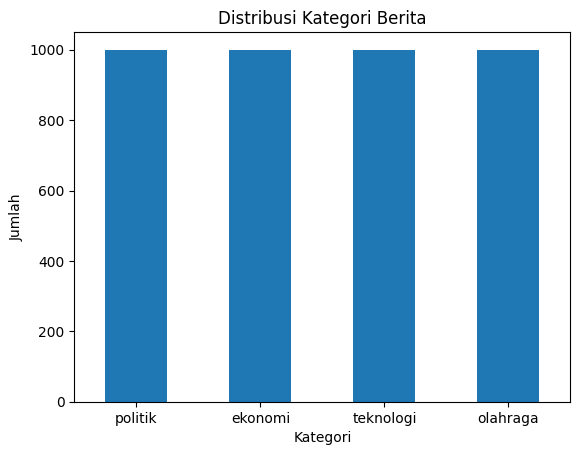

In [39]:
import matplotlib.pyplot as plt

plt.figure()
kategori_counts.plot(kind='bar')
plt.title("Distribusi Kategori Berita")
plt.xlabel("Kategori")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)
plt.show()

4. PANJANG DOKUMEN

In [40]:
df['panjang'] = df['isi_berita'].astype(str).apply(lambda x: len(x.split()))

print("Statistik panjang dokumen:")
print(df['panjang'].describe())

Statistik panjang dokumen:
count    4000.000000
mean      445.548500
std       254.610525
min        10.000000
25%       277.000000
50%       388.000000
75%       558.000000
max      5648.000000
Name: panjang, dtype: float64


5. HISTOGRAM PANJANG DOKUMEN

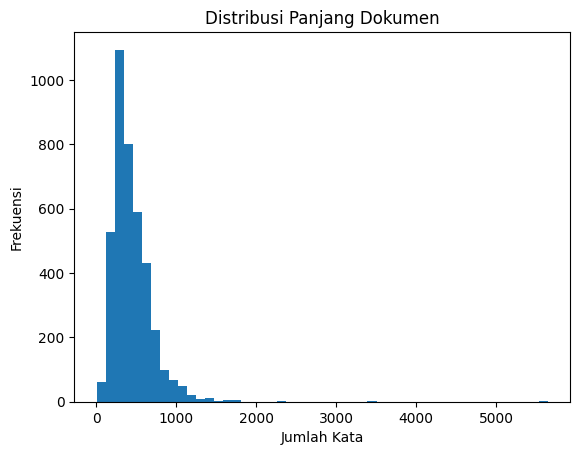

In [41]:
plt.figure()
plt.hist(df['panjang'], bins=50)
plt.title("Distribusi Panjang Dokumen")
plt.xlabel("Jumlah Kata")
plt.ylabel("Frekuensi")
plt.show()

6. TOP KATA SEBELUM PREPROCESSING

In [42]:
text_awal = " ".join(df['isi_berita'].astype(str))

text_awal = text_awal.lower()
text_awal = re.sub(r'[^a-zA-Z\s]', '', text_awal)

words_awal = text_awal.split()

counter_awal = Counter(words_awal)
print("Top 20 kata sebelum preprocessing:")
print(counter_awal.most_common(20))

Top 20 kata sebelum preprocessing:
[('yang', 39335), ('dan', 36216), ('di', 35908), ('ini', 16821), ('untuk', 16394), ('dari', 16049), ('dengan', 15726), ('dalam', 14796), ('pada', 13366), ('indonesia', 11813), ('juga', 10996), ('tidak', 9942), ('itu', 9767), ('menjadi', 8002), ('ke', 7622), ('akan', 7125), ('lebih', 6609), ('tersebut', 6430), ('sebagai', 6141), ('atau', 5103)]


7. MISSING VALUE

In [43]:
print("Missing value:")
print(df.isnull().sum())

Missing value:
id_berita     0
judul         0
isi_berita    0
kategori      0
panjang       0
dtype: int64


8. PREPROCESSING

In [44]:
# stopword
stop_factory = StopWordRemoverFactory()
stopwords = set(stop_factory.get_stop_words())

# stemmer
stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()

def preprocess(text):
    text = text.lower() # case folding
    text = re.sub(r'[^a-zA-Z\s]', '', text) # cleaning
    words = text.split() # tokenizing
    words = [w for w in words if w not in stopwords] # stopword
    text = " ".join(words)  # stemming
    text = stemmer.stem(text)  # lebih cepat
    return text

df['clean_text'] = df['isi_berita'].astype(str).apply(preprocess)

9. TOP KATA SETELAH PREPROCESSING

In [49]:
text_clean = " ".join(df['clean_text'])

words_clean = text_clean.split()

counter_clean = Counter(words_clean)

print("Top 20 kata setelah preprocessing:")
print(counter_clean.most_common(20))

Top 20 kata setelah preprocessing:
[('jadi', 12809), ('indonesia', 11835), ('sebut', 8375), ('lebih', 7005), ('kata', 6556), ('lalu', 4836), ('baca', 4678), ('laku', 4614), ('perintah', 4576), ('kerja', 4490), ('tahun', 4420), ('besar', 4383), ('hingga', 4328), ('ekonomi', 4267), ('sama', 4054), ('kuat', 3914), ('tingkat', 3885), ('negara', 3869), ('satu', 3805), ('jakarta', 3774)]


10. PERBANDINGAN SEBELUM vs SESUDAH

In [50]:
df[['isi_berita', 'clean_text']].head()

,isi_berita,clean_text
0,Menteri Sekretaris Negara (Mensesneg) Prasetyo...,menteri sekretaris negara mensesneg prasetyo h...
1,KETUA Umum Partai Kebangkitan Bangsa Abdul Muh...,ketua umum partai bangkit bangsa abdul muhaimi...
2,Surabaya (ANTARA) - Wakil Ketua Dewan Perwakil...,surabaya wakil ketua dewan wakil rakyat daerah...
3,Jakarta (ANTARA) - Presiden Prabowo Subianto m...,jakarta presiden prabowo subianto kata hasil d...
4,Jakarta (ANTARA) - Wakil Ketua Umum DPP Partai...,jakarta wakil ketua umum dpp partai bangkit ba...


11. VOCABULARY SIZE

In [47]:
vocab_before = len(set(words_awal))
vocab_after = len(set(words_clean))

print("Jumlah kata unik sebelum preprocessing:", vocab_before)
print("Jumlah kata unik setelah preprocessing:", vocab_after)

Jumlah kata unik sebelum preprocessing: 44704
Jumlah kata unik setelah preprocessing: 34470


12. PANJANG JUDUL

In [48]:
df['panjang_judul'] = df['judul'].astype(str).apply(lambda x: len(x.split()))

print("Statistik panjang judul:")
print(df['panjang_judul'].describe())

Statistik panjang judul:
count    4000.000000
mean        9.087750
std         1.839265
min         1.000000
25%         8.000000
50%         9.000000
75%        10.000000
max        15.000000
Name: panjang_judul, dtype: float64
